# Follow the Money - EXTRACTING AND VIZUALIZING RESULTS

#### Technical notes: 

Run each cell in order - the code builds on itself so if an error comes up make sure all the cells above it have been run

To run either: 
- click on the cell you want to run and click 'RUN' or the play button in the headings bar
- OR select the cell and press 'ENTER' + 'SHIFT'

In [21]:
#imports
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

### Options to choose:
1) Company or Companies
   - The rest of the code will anaylse the top French projects that this company particpated in
   - You can pick multiple companies at once but the code will combine the results and not all steps distinguish between each company in the totals
3) Programs to analyze:
   - 1 = Horizon Europe (2021 - 2027)
   - 2 = Horizon 2020 (2014 - 2020)
   - 3 = FP7 (2007 - 2013)
   - 4 = FP6 (2002 - 2006), note: this dataset is messy and has missing information so it may skew the results
4) Keywords: this will search in the official keywords 'EuroSciVoc' listed for the top prjects. 
   - You can leave this list empty and it will plot all of the keywords or you can pick some (ie 'energy and fuels','artificial intelligence') and it will count how many times those keywords are used to describe the projects


In [22]:
# 1) pick a company to analyse (can pick multiple but picking a single one first is suggested)
Entreprises = ['AIRBUS'] 

# 2) Choose over which programs you want to analyze
Prog = {1: 'HORIZON', 2: 'H2020', 3: 'FP7', 4: 'FP6'}
IncludeProgrammes = [1,2,3] #FP6 dataset is messy and has missing information so it may skew the results

# 3) Pick the keywords you want information on
KeyWords = [] # you can leave this list empty and it will plot all of the keywords

### Get Clean Data

In [4]:
## use this one when accessing data file from GitHub -- ie when using BINDER link
Clean_file = 'EU-fundings-TopFRcomp.csv'

TypeSpec = {'ecContribution': float,'Source': int,'Start Date': str,'netEcContribution': str} 
EUfullTable = pd.read_csv(Clean_file,dtype = TypeSpec) 
EUfullTable['EuroSciVoc'] = EUfullTable['EuroSciVoc'].fillna('[]').apply(lambda x: eval(x))

SourceSelect = EUfullTable['source'].apply(lambda x: x in IncludeProgrammes)
EUfullTable = EUfullTable.loc[SourceSelect]

SDateSeries = EUfullTable['Start Date'].str[0:4].fillna('9999').apply(lambda x: int(x))

'''
## use this one when accessing data file from laptop

CleanFolderName = '/Users/annalewicki/Downloads/Horizon Terre/Future Earth Atelier/code/' #replace with file location on your PC
Clean_file = 'EU-fundings-TopFRcomp.csv'

TypeSpec = {'ecContribution': float,'Source': int,'Start Date': str,'netEcContribution': str} 
EUfullTable = pd.read_csv(CleanFolderName + Clean_file,dtype = TypeSpec) 
EUfullTable['EuroSciVoc'] = EUfullTable['EuroSciVoc'].fillna('[]').apply(lambda x: eval(x))

SourceSelect = EUfullTable['source'].apply(lambda x: x in IncludeProgrammes)
EUfullTable = EUfullTable.loc[SourceSelect]

SDateSeries = EUfullTable['Start Date'].str[0:4].fillna('9999').apply(lambda x: int(x))
'''

"\n\n## use this one when accessing data file from GitHub\nClean_file = 'EU-fundings-TopFRcomp-withAbstract.csv'\n\nTypeSpec = {'ecContribution': float,'Source': int,'Start Date': str,'netEcContribution': str} \nEUfullTable = pd.read_csv(Clean_file,dtype = TypeSpec) \nEUfullTable['EuroSciVoc'] = EUfullTable['EuroSciVoc'].fillna('[]').apply(lambda x: eval(x))\n\nSourceSelect = EUfullTable['source'].apply(lambda x: x in IncludeProgrammes)\nEUfullTable = EUfullTable.loc[SourceSelect]\n\nSDateSeries = EUfullTable['Start Date'].str[0:4].fillna('9999').apply(lambda x: int(x))\n"

### Find projects that chosen company is a part of from Clean Data (EU Fundings-TopFRcomp)

In [11]:
Entreprises = [x.upper() for x in Entreprises] # Put names all in capital letters 

if Entreprises != []: 
    IncludeTable = EUfullTable[['projectAcronym','Company']].groupby('projectAcronym').max()
    IncludeGroupIndex = IncludeTable['Company'].apply(lambda x: x in Entreprises)
    IncludeAc = set(IncludeTable['Company'].loc[IncludeGroupIndex].keys())
    IncludeIndex = EUfullTable['projectAcronym'].apply(lambda x: x in IncludeAc)
    EUfullTable = EUfullTable.loc[IncludeIndex]
else: 
    print(' ')
    print('COMPANY LIST EMPTY ! STATS ARE SHOWN FOR FULL LIST !')


##################### EXTRACT SERIES #####################

AcSeries = EUfullTable['projectAcronym']
SDateSeries = EUfullTable['Start Date']
LabsAndTOPSeries = EUfullTable['name']
TOPmainSeries = EUfullTable['Company']
FundSeries = EUfullTable['ecContribution']
CountrySeries = EUfullTable['country']

Nt = AcSeries.size # Total line number 


#### Calculate the Total Funding Company Recieves and Top 3 Funded Projects

In [20]:
###Top 3 Projects Recieving the most EU funding
TotalNum_Prog = EUfullTable[['projectAcronym','source']].groupby('projectAcronym').max().reset_index()
TotalNum_Prog = TotalNum_Prog['source'].value_counts()
TotalNum_Prog = TotalNum_Prog.rename(index = Prog) 
TotalNum_Prog['Somme total'] = np.sum(TotalNum_Prog)
TotalNum_ProgR = TotalNum_Prog[::-1] # Reverse order

###Total Funds per program
TotalFunds_Prog = EUfullTable[['ecContribution','source']].groupby('source',group_keys=False).sum()
TotalFunds_Prog = TotalFunds_Prog['ecContribution'].rename_axis(None, axis=0) 
TotalFunds_Prog = TotalFunds_Prog.rename(index = Prog).apply(lambda x: np.round(x/1e6)) # In Millions euros
TotalFunds_Prog['Somme total'] = np.sum(TotalFunds_Prog)
TotalFunds_ProgR = TotalFunds_Prog[::-1] # Reverse order

###Total funding per project
Project_TotFunds = EUfullTable[['projectAcronym','ecContribution','EuroSciVoc']].groupby('projectAcronym').sum().reset_index()
Project_TotFunds['EuroSciVoc'] = Project_TotFunds['EuroSciVoc'].apply(lambda x: list(set(x)))
Project_TotFunds = Project_TotFunds.sort_values('ecContribution',ascending=False) 
Project_TotFunds['ecContribution'] = Project_TotFunds['ecContribution'].apply(lambda x: x/1e6)

Ntop_TotFunds = 3 # Number of highest projects to select  
Top3Project_TotFunds = Project_TotFunds.iloc[0:Ntop_TotFunds]

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Main Info
##### prints the calculations done above

In [14]:
print(' ')
print('Total Sum (in M €):')
print(TotalFunds_Prog)

print(' ')
print('Top  projets:')
print(Top3Project_TotFunds)

print(' ')
print('Number of projets:')
print(TotalNum_Prog)

 
Total Sum (in M €):
HORIZON         548.0
H2020           647.0
FP7             536.0
Somme total    1731.0
Name: ecContribution, dtype: float64
 
Top  projets:
    projectAcronym  ecContribution  \
107   FRC GAM 2018       85.997328   
252        UNIFIED       76.715151   
189         PHARES       69.026927   

                                            EuroSciVoc  
107  [energy and fuels, aeronautical engineering, m...  
252                       [aircraft, energy and fuels]  
189                       [aircraft, energy and fuels]  
 
Number of projets:
source
FP7            123
H2020           85
HORIZON         51
Somme total    259
Name: count, dtype: int64


### Plot Set up

In [15]:
Font=14
plt.rc('text', usetex=False) # FORCE NO LATEX
plt.rc('font',size=Font)
plt.rc('font',family='serif')

## Plot: NUMBER OF PROJECTS PER PROGRAMME

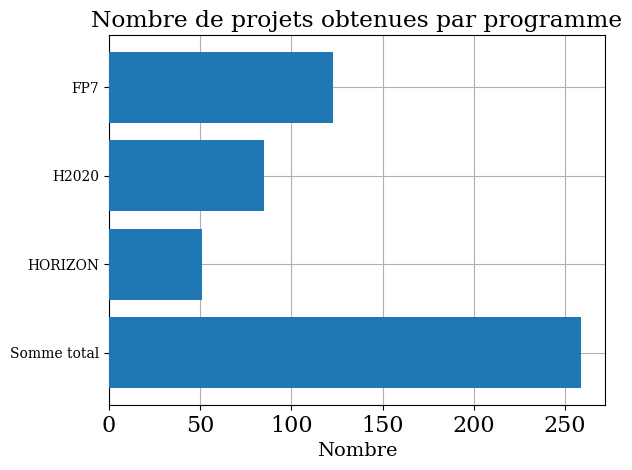

In [16]:
"""
#####################
# Comp. number of projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(TotalNum_ProgR.index,TotalNum_ProgR,color = 'tab:blue',zorder=3) 
plt.grid()
plt.title('Nombre de projets obtenues par programme')
plt.xlabel('Nombre')
plt.show()

## Plot: FUNDINGS PER PROGRAMME 

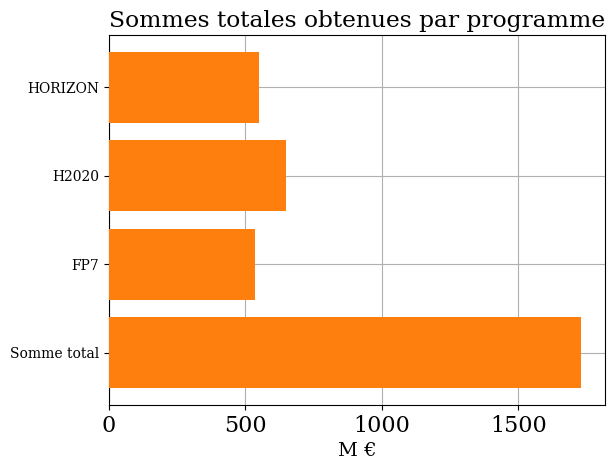

In [17]:
"""
#####################
# Comp. fundings of projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(TotalFunds_ProgR.index,TotalFunds_ProgR,color = 'tab:orange',zorder=3) 
plt.grid()
plt.title('Sommes totales obtenues par programme')
plt.xlabel('M €')
plt.show()

## Plot: FUNDINGS PER PROJECT 

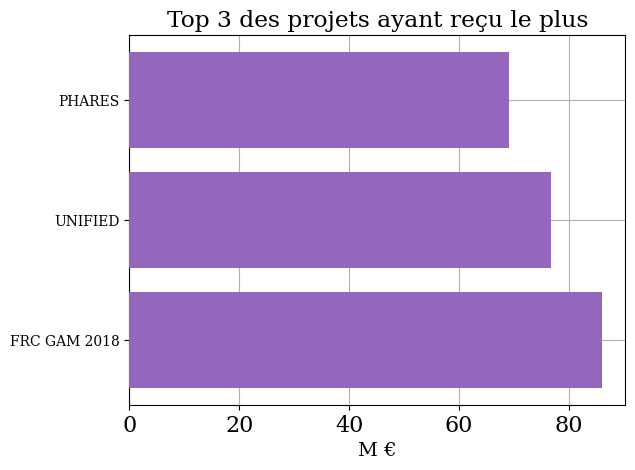

In [18]:
"""
#####################
# Top 3 projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(Top3Project_TotFunds['projectAcronym'],Top3Project_TotFunds['ecContribution'],color = 'tab:purple',zorder=3) 
plt.grid()
plt.title('Top '+str(Ntop_TotFunds)+' des projets ayant reçu le plus')
plt.xlabel('M €')
plt.show()


## KEYWORDS STATS 

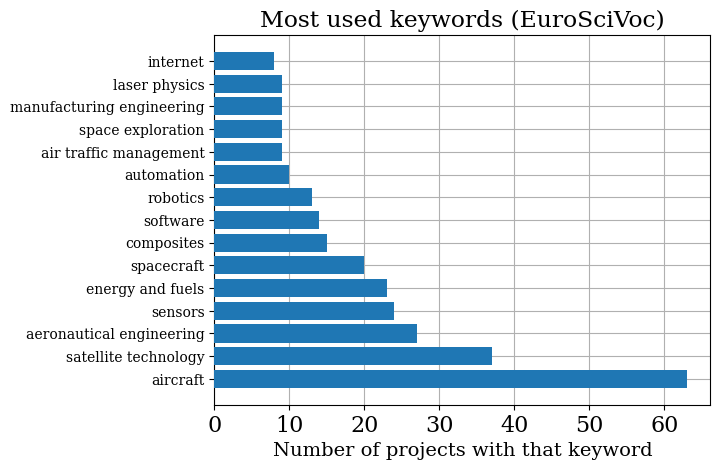

In [19]:
KeyWords_Nlist = list(EUfullTable.drop_duplicates(subset=['projectAcronym'])['EuroSciVoc']) # gives a nested list 
KeyWords_list = [item for sublist in KeyWords_Nlist for item in sublist] # Flatten the nested list 
KeyWords_set = set(KeyWords_list)

KeyWords_Count = pd.Series(KeyWords_list).value_counts() 
Nkw = 15 # Number of keywords to show 

KeyWords_RCount = KeyWords_Count.iloc[0:Nkw] 

if len(KeyWords) > 0: 
    for jk in KeyWords: 
        if jk not in KeyWords_set: 
            print(' ')
            print('Keyword "'+jk+'" not in the standard EuroSciVoc list! Has been removed.')
            KeyWords.remove(jk) 
    KeyWords_selected_index = pd.Series(KeyWords_Count.index).apply(lambda x: x in KeyWords)
    KeyWords_selected_index.index = KeyWords_Count.index 
    KeyWords_selected = KeyWords_Count.loc[KeyWords_selected_index] 

"""
#####################
#   Keywords count 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
if len(KeyWords)>0: 
    plt.figure() 
    plt.barh(KeyWords_selected.index,KeyWords_selected,zorder=3) 
    plt.grid()
    plt.title('Occurences of chosen keywords (EuroSciVoc)')
    plt.xlabel('Number of projects with that keyword')
else: 
    plt.figure() 
    plt.barh(KeyWords_RCount.index,KeyWords_RCount,zorder=3) 
    plt.grid()
    plt.title('Most used keywords (EuroSciVoc)')
    plt.xlabel('Number of projects with that keyword')

plt.show()